# Unsupervised Learning Project: A Reproducible Experimental Study of Clustering

**Team composition:** Luí­s Serrano (60253), Tiago Fonseca (72898), Miguel Teixeira (72922)

**Project title:** Booking Archetype Clustering in Hotel Booking


## Problem Framing
- **Q:** Do hotel bookings cluster into distinct booking profiles based on pre-arrival characteristics, and do these profiles exhibit consistent patterns in other booking dimensions?


## Short Data Documentation

In [10]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path(".")
df = pd.read_csv(DATA_DIR / "hotel_bookings_course_release_v1.csv")

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))


Dataset shape: (119390, 32)
Columns: 32


## Final Include/Exclude Decisions for Clustering


In [11]:
raw_clustering_features = [
    "hotel",
    "lead_time",
    "arrival_date_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

exclude_features = {
    "is_canceled": "Outcome/post-event leakage",
    "reservation_status": "Outcome/post-event leakage",
    "reservation_status_date": "Outcome/post-event leakage",
    "agent": "ID-like high-cardinality feature",
    "company": "ID-like high-cardinality feature with very high missingness",
    "assigned_room_type": "post-booking operational field",
    "booking_changes": "post-booking operational field",
    "days_in_waiting_list": "post-booking operational field",
    "arrival_date_year": "Redundant temporal context for this setup",
    "arrival_date_week_number": "Redundant temporal context for this setup",
    "arrival_date_day_of_month": "Redundant temporal context for this setup",
    "meal": "Reserved for post-hoc profiling",
    "adr": "Reserved for post-hoc profiling",
}

X = df[raw_clustering_features].copy()
posthoc_only = ["meal", "adr", "is_canceled", "reservation_status"]

final_feature_map = {
    "arrival_date_month": "arrival_season",
    "country": "country_group",
    "children": "minor_count",
    "babies": "minor_count",
    "stays_in_weekend_nights": "total_nights",
    "stays_in_week_nights": "total_nights",
}

included_feature_rows = [
    {
        "feature": feature,
        "final_feature": final_feature_map.get(feature, feature),
        "decision": "include_candidate",
        "stage": "raw_clustering_input",
        "reason": "Known at booking creation; final representation may transform, group, or combine this raw field.",
    }
    for feature in raw_clustering_features
]
excluded_feature_rows = [
    {
        "feature": feature,
        "final_feature": pd.NA,
        "decision": "exclude",
        "stage": "raw_dataset_column",
        "reason": reason,
    }
    for feature, reason in exclude_features.items()
]
feature_selection_table = pd.DataFrame(included_feature_rows + excluded_feature_rows)
feature_selection_table.to_csv(DATA_DIR / "feature_selection_table.csv", index=False)

print("Raw clustering feature count:", len(raw_clustering_features))
print("Excluded count:", len(exclude_features))
display(feature_selection_table)
print("Exported: feature_selection_table.csv")


Raw clustering feature count: 19
Excluded count: 13


,feature,final_feature,decision,stage,reason
0,hotel,hotel,include_candidate,raw_clustering_input,Known at booking creation; final representatio...
1,lead_time,lead_time,include_candidate,raw_clustering_input,Known at booking creation; final representatio...
2,arrival_date_month,arrival_season,include_candidate,raw_clustering_input,Known at booking creation; final representatio...
3,stays_in_weekend_nights,total_nights,include_candidate,raw_clustering_input,Known at booking creation; final representatio...
4,stays_in_week_nights,total_nights,include_candidate,raw_clustering_input,Known at booking creation; final representatio...
5,adults,adults,include_candidate,raw_clustering_input,Known at booking creation; final representatio...
6,children,minor_count,include_candidate,raw_clustering_input,Known at booking creation; final representatio...
7,babies,minor_count,include_candidate,raw_clustering_input,Known at booking creation; final representatio...
8,country,country_group,include_candidate,raw_clustering_input,Known at booking creation; final representatio...
9,market_segment,market_segment,include_candidate,raw_clustering_input,Known at booking creation; final representatio...


Exported: feature_selection_table.csv


## Representation Details

In [12]:
month_to_season = {
    "December": "Winter", "January": "Winter", "February": "Winter",
    "March": "Spring", "April": "Spring", "May": "Spring",
    "June": "Summer", "July": "Summer", "August": "Summer",
    "September": "Autumn", "October": "Autumn", "November": "Autumn",
}

def group_country(code):
    if pd.isna(code):
        return "Other"
    if code == "PRT":
        return "Portugal"
    if code == "ESP":
        return "Spain"
    if code in {"GBR", "IRL"}:
        return "British Isles"
    if code in {"FRA", "BEL", "NLD", "LUX"}:
        return "Western Europe"
    if code in {"DEU", "AUT", "CHE"}:
        return "DACH"
    if code in {"ITA", "GRC", "MLT", "CYP"}:
        return "Southern Europe"
    if code in {"SWE", "NOR", "DNK", "FIN", "ISL"}:
        return "Nordics"
    if code in {"POL", "ROU", "RUS", "UKR", "CZE", "SVK", "HUN", "BGR", "SRB", "HRV", "SVN", "EST", "LVA", "LTU", "BLR"}:
        return "Eastern Europe"
    if code in {"BRA", "ARG", "CHL", "COL", "MEX", "PER", "URY", "VEN", "ECU", "BOL", "PRY", "DOM", "CUB", "PAN", "CRI", "GTM", "HND", "SLV", "NIC", "JAM", "TTO"}:
        return "Latin America"
    if code in {"USA", "CAN"}:
        return "Other"
    if code in {"CHN", "CN", "JPN", "KOR", "IND", "THA", "MYS", "SGP", "IDN", "VNM", "PHL", "TWN", "HKG", "MAC"}:
        return "Asia"
    if code in {"ISR", "SAU", "ARE", "QAT", "KWT", "OMN", "BHR", "JOR", "LBN", "IRN", "IRQ", "TUR"}:
        return "Other"
    if code in {"AUS", "NZL"}:
        return "Other"
    if code in {"ZAF", "MAR", "DZA", "TUN", "EGY", "NGA", "KEN", "ETH", "GHA", "AGO", "MOZ"}:
        return "Other"
    return "Other"

rare_reserved_room_types = {"G", "B", "C", "H", "P", "L"}

def group_reserved_room_type(room_type):
    if pd.isna(room_type):
        return "Other"
    room_type = str(room_type)
    if room_type in rare_reserved_room_types:
        return "Other"
    return room_type

rare_distribution_channels = {"GDS", "Undefined"}
rare_market_segments = {"Undefined", "Aviation", "Complementary"}

def group_distribution_channel(channel):
    if pd.isna(channel):
        return "Other"
    channel = str(channel)
    if channel in rare_distribution_channels:
        return "Other"
    return channel

def group_market_segment(segment):
    if pd.isna(segment):
        return "Other"
    segment = str(segment)
    if segment in rare_market_segments:
        return "Other"
    return segment

minor_count = X["children"].fillna(0) + X["babies"].fillna(0)
total_nights = X["stays_in_weekend_nights"].fillna(0) + X["stays_in_week_nights"].fillna(0)

X = X.assign(
    arrival_season=X["arrival_date_month"].map(month_to_season),
    country_group=X["country"].apply(group_country),
    distribution_channel=X["distribution_channel"].apply(group_distribution_channel),
    market_segment=X["market_segment"].apply(group_market_segment),
    reserved_room_type=X["reserved_room_type"].apply(group_reserved_room_type),
    previous_cancellations=X["previous_cancellations"].clip(upper=5),
    previous_bookings_not_canceled=X["previous_bookings_not_canceled"].clip(upper=5),
    adults=X["adults"].clip(upper=4),
    minor_count=minor_count.clip(upper=4),
    total_nights=total_nights.clip(upper=20),
)
valid_booking_mask = (X["distribution_channel"] != "Other") & (X["customer_type"] != "Other")
removed_rows = int((~valid_booking_mask).sum())

df = df.loc[valid_booking_mask].reset_index(drop=True)
X = X.loc[valid_booking_mask].copy()
X = X.drop(columns=["arrival_date_month", "country", "children", "babies", "stays_in_weekend_nights", "stays_in_week_nights"]).reset_index(drop=True)

print("Removed rows with distribution_channel/customer_type = Other:", removed_rows)
print("Engineered clustering matrix shape:", X.shape)
display(X.head())


Removed rows with distribution_channel/customer_type = Other: 198
Engineered clustering matrix shape: (119192, 17)


,hotel,lead_time,adults,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,customer_type,required_car_parking_spaces,total_of_special_requests,arrival_season,country_group,minor_count,total_nights
0,Resort Hotel,342,2,Direct,Direct,0,0,0,Other,No Deposit,Transient,0,0,Summer,Portugal,0.0,0
1,Resort Hotel,737,2,Direct,Direct,0,0,0,Other,No Deposit,Transient,0,0,Summer,Portugal,0.0,0
2,Resort Hotel,7,1,Direct,Direct,0,0,0,A,No Deposit,Transient,0,0,Summer,British Isles,0.0,1
3,Resort Hotel,13,1,Corporate,Corporate,0,0,0,A,No Deposit,Transient,0,0,Summer,British Isles,0.0,1
4,Resort Hotel,14,2,Online TA,TA/TO,0,0,0,A,No Deposit,Transient,0,1,Summer,British Isles,0.0,2


## Missingness and Outliers by Attribute Type



In [13]:
num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(exclude="number").columns.tolist()

treatment_notes = pd.DataFrame([
    {"feature": "adults", "action": "top-code at 4+", "reason": "Very large adult counts are exceptionally rare and can dominate Euclidean distance."},
    {"feature": "minor_count", "action": "combine children + babies; top-code at 3+", "reason": "Presence of minors is a key segmentation signal, not an outlier pattern."},
    {"feature": "country_group", "action": "keep Portugal and Spain separate; merge very small geographic groups into Other", "reason": "Reduces sparsity while preserving the distinction between the two largest Iberian origins."},
    {"feature": "reserved_room_type", "action": "group G/B/C/H/P/L into NUMOTHER", "reason": "Rare room categories are meaningful but too sparse to leave as separate one-hot levels."},
    {"feature": "distribution_channel", "action": "group GDS/Undefined into Other", "reason": "These levels are very sparse and are not stable enough as separate one-hot categories."},
    {"feature": "market_segment", "action": "group Undefined/Aviation/Complementary into Other", "reason": "These small or ambiguous segments are grouped to reduce categorical sparsity."},
    {"feature": "previous_cancellations / previous_bookings_not_canceled", "action": "top-code at 5+; scale without log-transform", "reason": "Large booking-history counts are rare; top-coding limits leverage while preserving the count scale."},
    {"feature": "total_nights", "action": "top-code at 20+", "reason": "Very long stays are rare and can dominate Euclidean distance."},
    {"feature": "lead_time", "action": "keep raw for reporting; log-transform during preprocessing", "reason": "Strong right skew can otherwise distort distance-based clustering."},
])
print("Feature-treatment summary:")
display(treatment_notes)
treatment_notes.to_csv(DATA_DIR / "feature_treatment_table.csv", index=False)

X_missing = df[raw_clustering_features].copy()
num_features_raw = X_missing.select_dtypes(include="number").columns.tolist()
cat_features_raw = X_missing.select_dtypes(exclude="number").columns.tolist()

missing_num = X_missing[num_features_raw].isna().sum().rename("missing_count").to_frame()
missing_num["missing_pct"] = (100 * missing_num["missing_count"] / len(X_missing)).round(4)
missing_cat = X_missing[cat_features_raw].isna().sum().rename("missing_count").to_frame()
missing_cat["missing_pct"] = (100 * missing_cat["missing_count"] / len(X_missing)).round(4)
missingness_table = pd.concat([
    missing_num.assign(attribute_type="numeric"),
    missing_cat.assign(attribute_type="categorical"),
]).rename_axis("feature").reset_index()
missingness_table = missingness_table[["feature", "attribute_type", "missing_count", "missing_pct"]]
missingness_table = missingness_table.sort_values(["missing_count", "feature"], ascending=[False, True])
missingness_table.to_csv(DATA_DIR / "missingness_table.csv", index=False)

print("Raw numerical missingness (clustering candidates before feature engineering):")
display(missing_num.sort_values("missing_count", ascending=False))
print("Raw categorical missingness (clustering candidates before feature engineering):")
display(missing_cat.sort_values("missing_count", ascending=False))

outlier_rows = []
for c in num_features:
    s = X[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (X[c] < low) | (X[c] > high)
    outlier_rows.append({
        "feature": c,
        "lower_bound": low,
        "upper_bound": high,
        "outlier_count": int(mask.sum()),
        "outlier_pct": round(float(100 * mask.mean()), 4),
    })
outliers_num = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
print("Numerical outliers (IQR diagnostic, before preprocessing transforms):")
display(outliers_num)

cat_rows = []
for c in cat_features:
    vc = X[c].value_counts(dropna=False, normalize=True).mul(100)
    rare = vc[vc < 1]
    cat_rows.append({
        "feature": c,
        "n_levels": int(vc.shape[0]),
        "rare_levels_lt_1pct": int(rare.shape[0]),
        "obs_in_rare_levels_pct": round(float(rare.sum()), 4),
    })
outliers_cat = pd.DataFrame(cat_rows).sort_values(["rare_levels_lt_1pct", "obs_in_rare_levels_pct"], ascending=False)
print("Categorical rarity report:")
display(outliers_cat)

outlier_columns = [
    "feature",
    "attribute_type",
    "diagnostic",
    "lower_bound",
    "upper_bound",
    "outlier_count",
    "outlier_pct",
    "n_levels",
    "rare_levels_lt_1pct",
    "obs_in_rare_levels_pct",
]
outlier_table = pd.concat([
    outliers_num.assign(attribute_type="numeric", diagnostic="iqr_1_5"),
    outliers_cat.assign(attribute_type="categorical", diagnostic="rare_levels_lt_1pct"),
], ignore_index=True, sort=False).reindex(columns=outlier_columns)
outlier_table.to_csv(DATA_DIR / "outlier_table.csv", index=False)

print("Exported: feature_treatment_table.csv, missingness_table.csv, outlier_table.csv")


Feature-treatment summary:


,feature,action,reason
0,adults,top-code at 4+,Very large adult counts are exceptionally rare...
1,minor_count,combine children + babies; top-code at 3+,Presence of minors is a key segmentation signa...
2,country_group,keep Portugal and Spain separate; merge very s...,Reduces sparsity while preserving the distinct...
3,reserved_room_type,group G/B/C/H/P/L into NUMOTHER,Rare room categories are meaningful but too sp...
4,distribution_channel,group GDS/Undefined into Other,These levels are very sparse and are not stabl...
5,market_segment,group Undefined/Aviation/Complementary into Other,These small or ambiguous segments are grouped ...
6,previous_cancellations / previous_bookings_not...,top-code at 5+; scale without log-transform,Large booking-history counts are rare; top-cod...
7,total_nights,top-code at 20+,Very long stays are rare and can dominate Eucl...
8,lead_time,keep raw for reporting; log-transform during p...,Strong right skew can otherwise distort distan...


Raw numerical missingness (clustering candidates before feature engineering):


,missing_count,missing_pct
lead_time,0,0.0
stays_in_weekend_nights,0,0.0
stays_in_week_nights,0,0.0
adults,0,0.0
children,0,0.0
babies,0,0.0
is_repeated_guest,0,0.0
previous_cancellations,0,0.0
previous_bookings_not_canceled,0,0.0
required_car_parking_spaces,0,0.0


Raw categorical missingness (clustering candidates before feature engineering):


...

Numerical outliers (IQR diagnostic, before preprocessing transforms):


,feature,lower_bound,upper_bound,outlier_count,outlier_pct
1,adults,2.0,2.0,29531,24.7760
7,minor_count,0.0,0.0,9331,7.8285
5,required_car_parking_spaces,0.0,0.0,7415,6.2211
3,previous_cancellations,0.0,0.0,6484,5.4400
8,total_nights,-1.0,7.0,5255,4.4089
2,is_repeated_guest,0.0,0.0,3807,3.1940
4,previous_bookings_not_canceled,0.0,0.0,3618,3.0354
0,lead_time,-196.5,375.5,2982,2.5018
6,total_of_special_requests,-1.5,2.5,2877,2.4138


Categorical rarity report:


,feature,n_levels,rare_levels_lt_1pct,obs_in_rare_levels_pct
1,market_segment,6,1,0.8222
5,customer_type,4,1,0.4841
4,deposit_type,3,1,0.1359
0,hotel,2,0,0.0000
2,distribution_channel,3,0,0.0000
3,reserved_room_type,5,0,0.0000
6,arrival_season,4,0,0.0000
7,country_group,11,0,0.0000


Exported: feature_treatment_table.csv, missingness_table.csv, outlier_table.csv


## Histograms for Numerical and Categorical Features


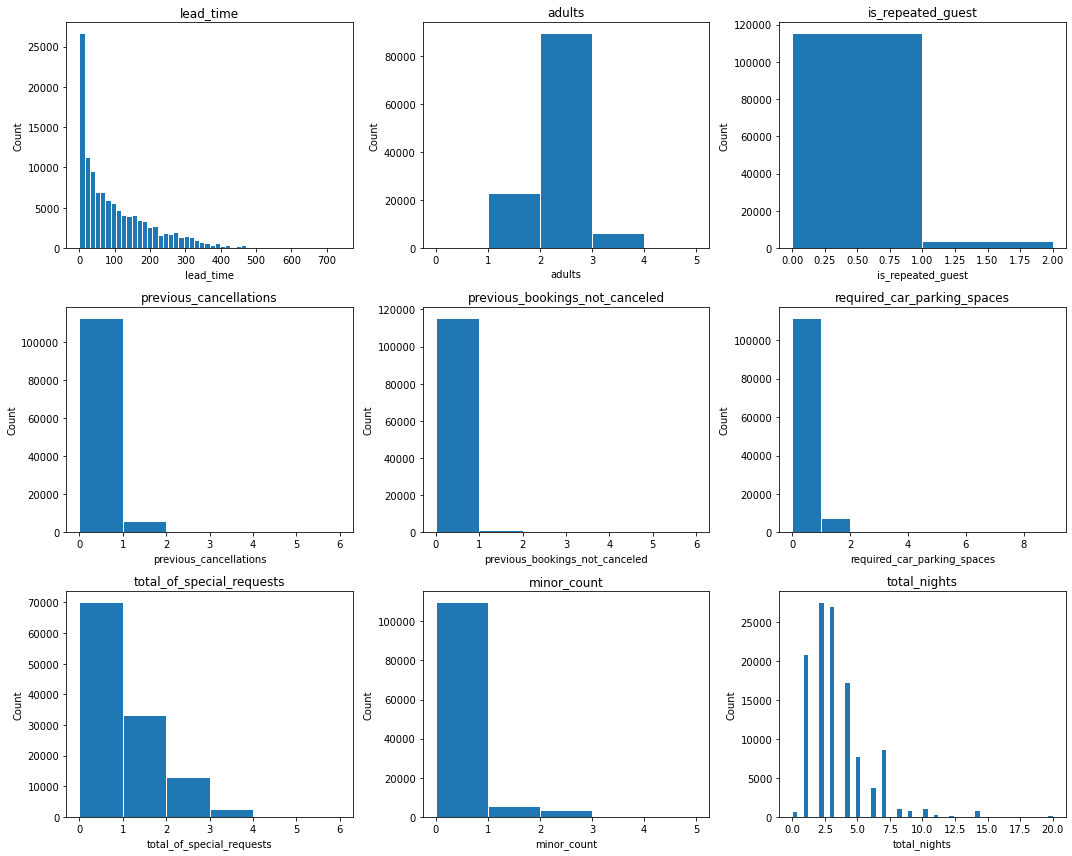

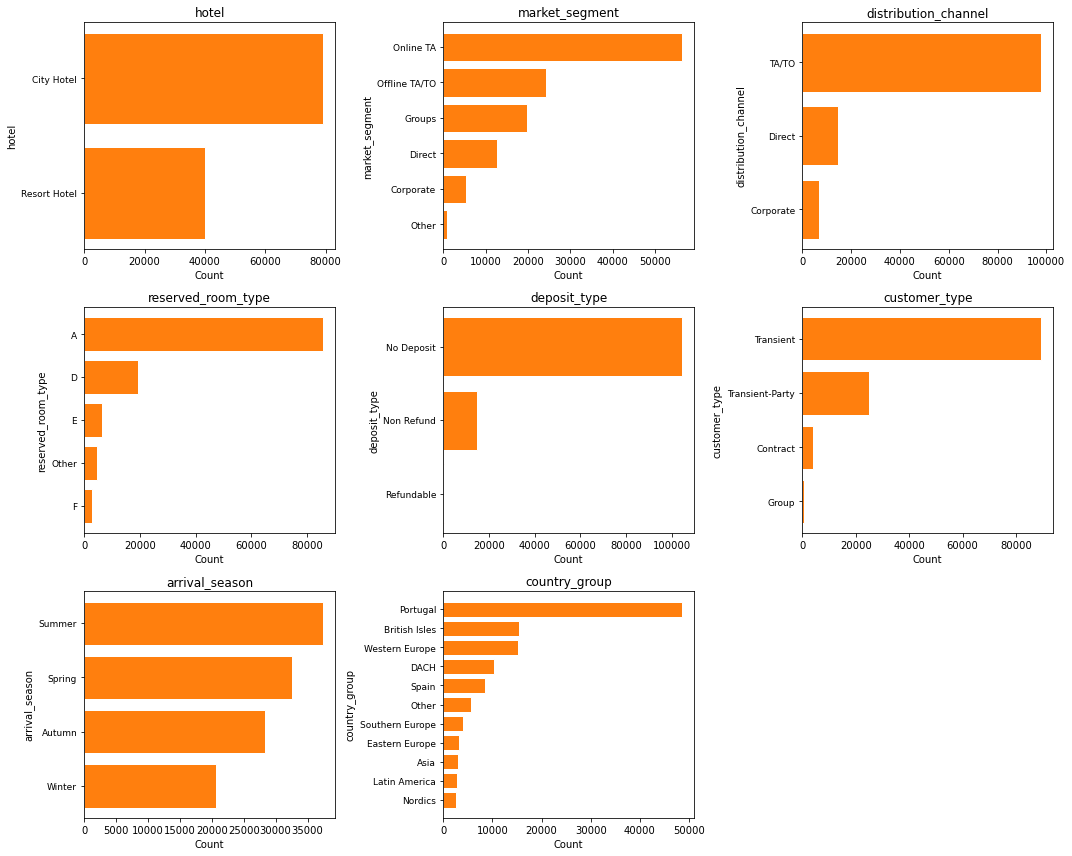

In [14]:
import matplotlib.pyplot as plt

if "num_features" not in globals():
    num_features = X.select_dtypes(include="number").columns.tolist()
if "cat_features" not in globals():
    cat_features = X.select_dtypes(exclude="number").columns.tolist()

hist_features = num_features
n_cols = 3
n_rows = (len(hist_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

for ax, feature in zip(axes, hist_features):
    values = X[feature].dropna()
    unique_values = values.nunique()
    if unique_values <= 20:
        bins = range(int(values.min()), int(values.max()) + 2)
    else:
        bins = 50

    ax.hist(values, bins=bins, edgecolor="white")
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

for ax in axes[len(hist_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

cat_plot_features = cat_features
top_n = 15
n_rows = (len(cat_plot_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

for ax, feature in zip(axes, cat_plot_features):
    values = X[feature].fillna("Missing").astype(str)
    counts = values.value_counts().head(top_n).sort_values()
    unique_values = values.nunique()
    title = feature if unique_values <= top_n else f"{feature} (top {top_n})"

    ax.barh(counts.index, counts.values, color="tab:orange", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel(feature)
    ax.tick_params(axis="y", labelsize=9)

for ax in axes[len(cat_plot_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## End-to-End Preprocessing Pipeline



In [15]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler, RobustScaler

num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(exclude="number").columns.tolist()

skewed_num_features = [
    "lead_time",
]
regular_num_features = [c for c in num_features if c not in skewed_num_features]

def build_preprocessor(scaler_cls):
    regular_numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler_cls()),
    ])

    skewed_numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", scaler_cls()),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num_regular", regular_numeric_pipeline, regular_num_features),
            ("num_skewed", skewed_numeric_pipeline, skewed_num_features),
            ("cat", categorical_pipeline, cat_features),
        ],
        remainder="drop",
    )

representation_id = "final_precluster_matrix"
representation_metric_sentence = (
    "Euclidean distance on the final transformed noADR booking matrix, "
    "with log1p-transformed lead_time, scaled numeric features, and full one-hot encoded categoricals."
)

preprocessor = build_preprocessor(StandardScaler)
X_prepared = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

pipeline_sketch = pd.DataFrame([
    {
        "column_transformer_branch": "num_regular",
        "input_columns": ", ".join(regular_num_features),
        "pipeline_steps": "SimpleImputer(strategy='median') -> StandardScaler",
        "output_role": "scaled numeric features",
    },
    {
        "column_transformer_branch": "num_skewed",
        "input_columns": ", ".join(skewed_num_features),
        "pipeline_steps": "SimpleImputer(strategy='median') -> FunctionTransformer(np.log1p) -> StandardScaler",
        "output_role": "log-transformed and scaled numeric features",
    },
    {
        "column_transformer_branch": "cat",
        "input_columns": ", ".join(cat_features),
        "pipeline_steps": "SimpleImputer(strategy='most_frequent') -> OneHotEncoder(handle_unknown='ignore', min_frequency=0.01, sparse_output=False)",
        "output_role": "one-hot encoded categorical features",
    },
    {
        "column_transformer_branch": "remainder",
        "input_columns": "all unspecified columns",
        "pipeline_steps": "drop",
        "output_role": "excluded from clustering matrix",
    },
])
pipeline_sketch.to_csv(DATA_DIR / "column_transformer_pipeline_sketch.csv", index=False)
pipeline_sketch.to_csv(DATA_DIR / "pipeline_sketch.csv", index=False)

print("Representation ID:", representation_id)
print("Metric sentence:", representation_metric_sentence)
print("Raw clustering matrix:", X.shape)
print("Prepared clustering matrix:", X_prepared.shape)
print("Regular numerical features:", regular_num_features)
print("Log-transformed numerical features:", skewed_num_features)
print("Categorical features:", cat_features)
print("Example transformed names:", feature_names[:25])
display(pipeline_sketch)

precluster_matrix_path = DATA_DIR / "final_precluster_matrix.csv"
precluster_matrix = pd.DataFrame(X_prepared, columns=feature_names)
precluster_matrix.to_csv(precluster_matrix_path, index=False)
print("Exported pipeline sketch: column_transformer_pipeline_sketch.csv, pipeline_sketch.csv")
print("Exported pre-clustering matrix:", precluster_matrix_path)
print("Pre-clustering CSV shape:", precluster_matrix.shape)


Representation ID: final_precluster_matrix
Metric sentence: Euclidean distance on the final transformed noADR booking matrix, with log1p-transformed lead_time, scaled numeric features, and full one-hot encoded categoricals.
Raw clustering matrix: (119192, 17)
Prepared clustering matrix: (119192, 47)
Regular numerical features: ['adults', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'required_car_parking_spaces', 'total_of_special_requests', 'minor_count', 'total_nights']
Log-transformed numerical features: ['lead_time']
Categorical features: ['hotel', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'arrival_season', 'country_group']
Example transformed names: ['num_regular__adults' 'num_regular__is_repeated_guest'
 'num_regular__previous_cancellations'
 'num_regular__previous_bookings_not_canceled'
 'num_regular__required_car_parking_spaces'
 'num_regular__total_of_special_requests' 'num_regular__minor

,column_transformer_branch,input_columns,pipeline_steps,output_role
0,num_regular,"adults, is_repeated_guest, previous_cancellati...",SimpleImputer(strategy='median') -> StandardSc...,scaled numeric features
1,num_skewed,lead_time,SimpleImputer(strategy='median') -> FunctionTr...,log-transformed and scaled numeric features
2,cat,"hotel, market_segment, distribution_channel, r...",SimpleImputer(strategy='most_frequent') -> One...,one-hot encoded categorical features
3,remainder,all unspecified columns,drop,excluded from clustering matrix


Exported pipeline sketch: column_transformer_pipeline_sketch.csv, pipeline_sketch.csv
Exported pre-clustering matrix: final_precluster_matrix.csv
Pre-clustering CSV shape: (119192, 47)


## Histogram of `log1p`-Transformed Lead Time


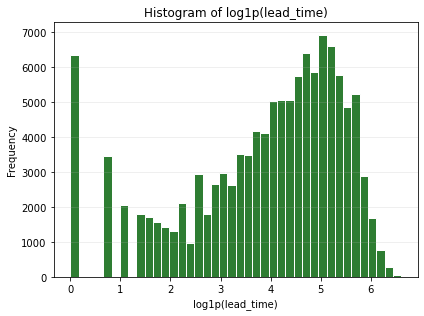

In [16]:
feature = "lead_time"
values_log = np.log1p(X[feature].dropna())

fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
ax.hist(values_log, bins=40, color="#2E7D32", edgecolor="white")
ax.set_title(f"Histogram of log1p({feature})")
ax.set_xlabel(f"log1p({feature})")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## Final Representation Declaration


In [17]:
representation_summary = pd.DataFrame([
    {
        "representation_id": representation_id,
        "segmentation_time": "booking creation",
        "adr_in_inputs": False,
        "numeric_scaler": "StandardScaler",
        "rare-country-strategy": "Portugal and Spain separated; North America, Middle East, Africa, Oceania, and Unknown merged into Other",
        "family-feature-strategy": "minor_count = children + babies",
        "rare-channel-segment-strategy": "distribution_channel GDS/Undefined grouped into Other; market_segment Undefined/Aviation/Complementary grouped into Other",
        "top-code-strategy": "previous_cancellations and previous_bookings_not_canceled capped at 5; total_nights capped at 20",
        "distance_metric": "Euclidean",
        "matrix_shape": str(X_prepared.shape),
    }
])
display(representation_summary)


,representation_id,segmentation_time,adr_in_inputs,numeric_scaler,rare-country-strategy,family-feature-strategy,rare-channel-segment-strategy,top-code-strategy,distance_metric,matrix_shape
0,final_precluster_matrix,booking creation,False,StandardScaler,"Portugal and Spain separated; North America, M...",minor_count = children + babies,distribution_channel GDS/Undefined grouped int...,previous_cancellations and previous_bookings_n...,Euclidean,"(119192, 47)"


## K-means Baselines and iK-means Evaluation (Same Protocol)



In [18]:
import time
from datetime import datetime

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from iKMeans import ikmeans_initialize

K_RANGE = [3, 4, 5, 6, 7, 8]
RANDOM_STATES = [7, 21, 42, 84, 123, 168, 256, 512, 1024, 2026]
IKM_MIN_CLUSTER_SIZE = 10

SIL_SAMPLE_SIZE = min(20000, X_prepared.shape[0])
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_prepared.shape[0], size=SIL_SAMPLE_SIZE, replace=False)
X_eval = X_prepared[sample_idx]

rows = []

# 1) KMeans baseline
for k in K_RANGE:
    for seed in RANDOM_STATES:
        model = KMeans(n_clusters=k, random_state=seed, n_init=20, max_iter=300)
        t0 = time.perf_counter()
        labels_full = model.fit_predict(X_prepared)
        fit_elapsed = time.perf_counter() - t0

        labels_eval = labels_full[sample_idx]
        rows.append({
            "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds"),
            "model": "kmeans",
            "k": k,
            "seed": seed,
            "init_seconds": 0.0,
            "fit_seconds": round(fit_elapsed, 4),
            "total_seconds": round(fit_elapsed, 4),
            "inertia": float(model.inertia_),
            "silhouette": float(silhouette_score(X_eval, labels_eval, metric="euclidean")),
            "calinski_harabasz": float(calinski_harabasz_score(X_eval, labels_eval)),
            "davies_bouldin": float(davies_bouldin_score(X_eval, labels_eval)),
            "min_cluster_share": float(pd.Series(labels_full).value_counts(normalize=True).min()),
            "ikm_extracted_clusters": np.nan,
        })

# 2) iKMeans initialization + downstream KMeans (same metrics protocol)
ikm_t0 = time.perf_counter()
ap_clusters, _init_std = ikmeans_initialize(
    X_prepared.astype(np.float64),
    min_cluster_size=IKM_MIN_CLUSTER_SIZE,
    tol=1e-12,
    max_iter=10_000,
    use_unit_ranges=False,
)
ikm_init_elapsed = time.perf_counter() - ikm_t0

ikm_retained = [c for c in ap_clusters if c.size >= IKM_MIN_CLUSTER_SIZE]
ikm_init_raw = np.vstack([c.centroid_raw for c in ikm_retained])
ikm_k = ikm_init_raw.shape[0]

ikm_model = KMeans(n_clusters=ikm_k, init=ikm_init_raw, n_init=1, max_iter=300, random_state=42)
fit_t0 = time.perf_counter()
ikm_labels_full = ikm_model.fit_predict(X_prepared)
ikm_fit_elapsed = time.perf_counter() - fit_t0

ikm_labels_eval = ikm_labels_full[sample_idx]
rows.append({
    "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds"),
    "model": "ikmeans",
    "k": int(ikm_k),
    "seed": -1,
    "init_seconds": round(ikm_init_elapsed, 4),
    "fit_seconds": round(ikm_fit_elapsed, 4),
    "total_seconds": round(ikm_init_elapsed + ikm_fit_elapsed, 4),
    "inertia": float(ikm_model.inertia_),
    "silhouette": float(silhouette_score(X_eval, ikm_labels_eval, metric="euclidean")),
    "calinski_harabasz": float(calinski_harabasz_score(X_eval, ikm_labels_eval)),
    "davies_bouldin": float(davies_bouldin_score(X_eval, ikm_labels_eval)),
    "min_cluster_share": float(pd.Series(ikm_labels_full).value_counts(normalize=True).min()),
    "ikm_extracted_clusters": int(len(ap_clusters)),
})

results = pd.DataFrame(rows)
summary = results.groupby(["model", "k"], as_index=False).agg(
    runs=("model", "count"),
    silhouette_mean=("silhouette", "mean"),
    silhouette_std=("silhouette", "std"),
    calinski_mean=("calinski_harabasz", "mean"),
    davies_mean=("davies_bouldin", "mean"),
    inertia_mean=("inertia", "mean"),
    init_seconds_mean=("init_seconds", "mean"),
    fit_seconds_mean=("fit_seconds", "mean"),
    total_seconds_mean=("total_seconds", "mean"),
    min_cluster_share_mean=("min_cluster_share", "mean"),
)

ikm_cluster_sizes = pd.Series(ikm_labels_full).value_counts().sort_index().rename("size")
baseline_results = summary.sort_values(["model", "silhouette_mean"], ascending=[True, False]).reset_index(drop=True)
ikm_cluster_share_table = (ikm_cluster_sizes / ikm_cluster_sizes.sum() * 100).round(2).rename("cluster_share_pct").to_frame()

results.to_csv(DATA_DIR / "baseline_run_results.csv", index=False)
baseline_results.to_csv(DATA_DIR / "baseline_results.csv", index=False)
ikm_cluster_share_table.to_csv(DATA_DIR / "ikmeans_cluster_share.csv")

experiments_path = DATA_DIR / "experiments.csv"
if experiments_path.exists():
    experiments_excerpt = pd.read_csv(experiments_path).head(8)
else:
    experiments_excerpt = baseline_results.head(8).copy()
experiments_excerpt.to_csv(DATA_DIR / "experiments_excerpt.csv", index=False)

display(baseline_results)
print("iKMeans extracted clusters (before min-size filtering):", len(ap_clusters))
print("iKMeans retained k:", ikm_k)
display(ikm_cluster_share_table)
print("Exported: baseline_results.csv, baseline_run_results.csv, ikmeans_cluster_share.csv, experiments_excerpt.csv")


,model,k,runs,silhouette_mean,silhouette_std,calinski_mean,davies_mean,inertia_mean,init_seconds_mean,fit_seconds_mean,total_seconds_mean,min_cluster_share_mean
0,ikmeans,48,1,0.116771,NaN,806.533192,2.007580,5.407019e+05,12.9341,1.18170,14.11570,0.007551
1,kmeans,8,10,0.145484,0.000413,2293.927869,1.639902,8.597199e+05,0.0000,8.40581,8.40581,0.032120
2,kmeans,7,10,0.137786,0.001638,2309.320917,1.734902,9.150577e+05,0.0000,9.33193,9.33193,0.032144
3,kmeans,6,10,0.134150,0.000078,2383.979599,1.774854,9.710704e+05,0.0000,7.85509,7.85509,0.033598
4,kmeans,5,10,0.127034,0.004804,2408.600696,1.859621,1.045877e+06,0.0000,7.27356,7.27356,0.033789
5,kmeans,4,10,0.121857,0.004367,2461.174116,2.011530,1.132007e+06,0.0000,8.27419,8.27419,0.033920
6,kmeans,3,10,0.112213,0.000058,2524.922872,2.292571,1.237168e+06,0.0000,6.59330,6.59330,0.034197


iKMeans extracted clusters (before min-size filtering): 48
iKMeans retained k: 48


,cluster_share_pct
0,1.21
1,2.05
2,4.44
3,1.41
4,2.03
5,2.52
6,3.35
7,2.13
8,1.29
9,1.36


Exported: baseline_results.csv, baseline_run_results.csv, ikmeans_cluster_share.csv, experiments_excerpt.csv


## Representation Robustness: StandardScaler vs RobustScaler



In [19]:
from itertools import combinations
from sklearn.metrics import adjusted_rand_score

representation_variants = [
    (representation_id, StandardScaler),
    ("robust_final_precluster_matrix", RobustScaler),
]

representation_rows = []
representation_matrices = {}
labels_by_rep_k_seed = {}

for rep_label, scaler_cls in representation_variants:
    rep_preprocessor = build_preprocessor(scaler_cls)
    X_rep = rep_preprocessor.fit_transform(X)
    representation_matrices[rep_label] = X_rep
    X_rep_eval = X_rep[sample_idx]

    for k in K_RANGE:
        for seed in RANDOM_STATES:
            model = KMeans(n_clusters=k, random_state=seed, n_init=20, max_iter=300)
            labels_full = model.fit_predict(X_rep)
            labels_by_rep_k_seed[(rep_label, k, seed)] = labels_full
            labels_eval = labels_full[sample_idx]
            representation_rows.append({
                "representation": rep_label,
                "k": k,
                "seed": seed,
                "silhouette": float(silhouette_score(X_rep_eval, labels_eval, metric="euclidean")),
                "calinski_harabasz": float(calinski_harabasz_score(X_rep_eval, labels_eval)),
                "davies_bouldin": float(davies_bouldin_score(X_rep_eval, labels_eval)),
                "min_cluster_share": float(pd.Series(labels_full).value_counts(normalize=True).min()),
            })

representation_sensitivity = pd.DataFrame(representation_rows)
representation_sensitivity_summary = representation_sensitivity.groupby(["representation", "k"], as_index=False).agg(
    runs=("seed", "count"),
    silhouette_mean=("silhouette", "mean"),
    silhouette_std=("silhouette", "std"),
    calinski_mean=("calinski_harabasz", "mean"),
    davies_mean=("davies_bouldin", "mean"),
    min_cluster_share_mean=("min_cluster_share", "mean"),
)
display(representation_sensitivity_summary.sort_values(["representation", "silhouette_mean"], ascending=[True, False]))

within_run_ari_rows = []
for rep_label, _ in representation_variants:
    for k in K_RANGE:
        for seed_a, seed_b in combinations(RANDOM_STATES, 2):
            labels_a = labels_by_rep_k_seed[(rep_label, k, seed_a)]
            labels_b = labels_by_rep_k_seed[(rep_label, k, seed_b)]
            within_run_ari_rows.append({
                "representation": rep_label,
                "k": k,
                "seed_a": seed_a,
                "seed_b": seed_b,
                "ari_between_runs": float(adjusted_rand_score(labels_a, labels_b)),
            })

representation_stability_ari = pd.DataFrame(within_run_ari_rows)
representation_stability_summary = representation_stability_ari.groupby(["representation", "k"], as_index=False).agg(
    run_pairs=("ari_between_runs", "count"),
    ari_between_runs_mean=("ari_between_runs", "mean"),
    ari_between_runs_std=("ari_between_runs", "std"),
    ari_between_runs_min=("ari_between_runs", "min"),
)
display(representation_stability_summary.sort_values(["representation", "ari_between_runs_mean"], ascending=[True, False]))

between_rep_ari_rows = []
standard_rep = representation_variants[0][0]
robust_rep = representation_variants[1][0]
for k in K_RANGE:
    for seed in RANDOM_STATES:
        labels_standard = labels_by_rep_k_seed[(standard_rep, k, seed)]
        labels_robust = labels_by_rep_k_seed[(robust_rep, k, seed)]
        between_rep_ari_rows.append({
            "k": k,
            "seed": seed,
            "ari_standard_vs_robust": float(adjusted_rand_score(labels_standard, labels_robust)),
        })
representation_ari = pd.DataFrame(between_rep_ari_rows)
representation_ari_summary = representation_ari.groupby("k", as_index=False).agg(
    runs=("seed", "count"),
    ari_standard_vs_robust_mean=("ari_standard_vs_robust", "mean"),
    ari_standard_vs_robust_std=("ari_standard_vs_robust", "std"),
    ari_standard_vs_robust_min=("ari_standard_vs_robust", "min"),
)
display(representation_ari_summary)

representation_sensitivity_summary.to_csv("representation_sensitivity_summary.csv", index=False)
representation_ari.to_csv("representation_sensitivity_ari.csv", index=False)
representation_ari_summary.to_csv("representation_sensitivity_ari_summary.csv", index=False)
representation_stability_ari.to_csv("representation_stability_ari.csv", index=False)
representation_stability_summary.to_csv("representation_stability_summary.csv", index=False)
print("Exported: representation_sensitivity_summary.csv, representation_sensitivity_ari.csv, representation_sensitivity_ari_summary.csv, representation_stability_ari.csv, representation_stability_summary.csv")


,representation,k,runs,silhouette_mean,silhouette_std,calinski_mean,davies_mean,min_cluster_share_mean
5,final_precluster_matrix,8,10,0.145484,0.000413,2293.927869,1.639902,0.032120
4,final_precluster_matrix,7,10,0.137786,0.001638,2309.320917,1.734902,0.032144
3,final_precluster_matrix,6,10,0.134150,0.000078,2383.979599,1.774854,0.033598
2,final_precluster_matrix,5,10,0.127034,0.004804,2408.600696,1.859621,0.033789
1,final_precluster_matrix,4,10,0.121857,0.004367,2461.174116,2.011530,0.033920
0,final_precluster_matrix,3,10,0.112213,0.000058,2524.922872,2.292571,0.034197
11,robust_final_precluster_matrix,8,10,0.131300,0.001935,1894.449813,1.984484,0.014907
9,robust_final_precluster_matrix,6,10,0.131256,0.005575,2111.336637,1.987793,0.044550
10,robust_final_precluster_matrix,7,10,0.128313,0.003413,1990.901971,2.028844,0.017401
7,robust_final_precluster_matrix,4,10,0.127025,0.000008,2608.702695,2.131499,0.144048


,representation,k,run_pairs,ari_between_runs_mean,ari_between_runs_std,ari_between_runs_min
5,final_precluster_matrix,8,45,0.999113,0.000511,0.998163
3,final_precluster_matrix,6,45,0.994061,0.003103,0.987813
0,final_precluster_matrix,3,45,0.993394,0.005212,0.987622
1,final_precluster_matrix,4,45,0.963354,0.062114,0.838690
2,final_precluster_matrix,5,45,0.767081,0.281016,0.342525
4,final_precluster_matrix,7,45,0.753327,0.212633,0.419819
6,robust_final_precluster_matrix,3,45,0.999329,0.000381,0.998756
7,robust_final_precluster_matrix,4,45,0.998883,0.000546,0.997795
8,robust_final_precluster_matrix,5,45,0.997058,0.001700,0.993993
10,robust_final_precluster_matrix,7,45,0.852071,0.096915,0.635303


,k,runs,ari_standard_vs_robust_mean,ari_standard_vs_robust_std,ari_standard_vs_robust_min
0,3,10,0.185616,0.000665,0.184646
1,4,10,0.283200,0.002374,0.281745
2,5,10,0.212955,0.046682,0.110190
3,6,10,0.317514,0.049176,0.243303
4,7,10,0.189779,0.070569,0.130479
5,8,10,0.265324,0.012506,0.257905


Exported: representation_sensitivity_summary.csv, representation_sensitivity_ari.csv, representation_sensitivity_ari_summary.csv, representation_stability_ari.csv, representation_stability_summary.csv


## Selection of K



In [20]:
kmeans_summary = summary[summary["model"] == "kmeans"].copy()
MIN_CLUSTER_SHARE = 0.01


share_rows = []
for k in K_RANGE:
    model_tmp = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels_tmp = model_tmp.fit_predict(X_prepared)
    min_share = pd.Series(labels_tmp).value_counts(normalize=True).min()
    share_rows.append({"k": k, "min_cluster_share": float(min_share)})
share_df = pd.DataFrame(share_rows)

selection_df = kmeans_summary.merge(share_df, on="k", how="left")
feasible = selection_df[selection_df["min_cluster_share"] >= MIN_CLUSTER_SHARE].copy()

if not feasible.empty:
    chosen_pool = feasible
    guardrail_msg = "Guardrail satisfied."
else:
    chosen_pool = selection_df
    guardrail_msg = "No k satisfies min-cluster-share guardrail; fallback to best silhouette."

chosen_pool = chosen_pool.sort_values(["silhouette_mean", "calinski_mean", "davies_mean"], ascending=[False, False, True])
selected_k = int(chosen_pool.iloc[0]["k"])

final_model = KMeans(n_clusters=selected_k, random_state=42, n_init=20, max_iter=300)
final_labels = final_model.fit_predict(X_prepared)
cluster_share = pd.Series(final_labels).value_counts(normalize=True).sort_index()

print(guardrail_msg)
print("Selected model: KMeans")
print("Selected k:", selected_k)
print("Min cluster share (%):", round(cluster_share.min() * 100, 2))
display(selection_df.sort_values("k"))
display((cluster_share * 100).rename("cluster_share_pct").to_frame())


Guardrail satisfied.
Selected model: KMeans
Selected k: 8
Min cluster share (%): 3.32


,model,k,runs,silhouette_mean,silhouette_std,calinski_mean,davies_mean,inertia_mean,init_seconds_mean,fit_seconds_mean,total_seconds_mean,min_cluster_share_mean,min_cluster_share
0,kmeans,3,10,0.112213,0.000058,2524.922872,2.292571,1.237168e+06,0.0,6.59330,6.59330,0.034197,0.034197
1,kmeans,4,10,0.121857,0.004367,2461.174116,2.011530,1.132007e+06,0.0,8.27419,8.27419,0.033920,0.033912
2,kmeans,5,10,0.127034,0.004804,2408.600696,1.859621,1.045877e+06,0.0,7.27356,7.27356,0.033789,0.033811
3,kmeans,6,10,0.134150,0.000078,2383.979599,1.774854,9.710704e+05,0.0,7.85509,7.85509,0.033598,0.033601
4,kmeans,7,10,0.137786,0.001638,2309.320917,1.734902,9.150577e+05,0.0,9.33193,9.33193,0.032144,0.033358
5,kmeans,8,10,0.145484,0.000413,2293.927869,1.639902,8.597199e+05,0.0,8.40581,8.40581,0.032120,0.033173


,cluster_share_pct
0,3.317337
1,22.196960
2,5.278039
3,15.709947
4,6.909021
5,31.627123
6,10.438620
7,4.522955


## Initial Cluster Interpretation and Post-hoc Profiling



In [21]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

profile_df = X.copy()
profile_df["cluster"] = final_labels

cluster_size = (profile_df["cluster"].value_counts(normalize=True).sort_index() * 100).round(2)
cluster_size_df = cluster_size.rename("cluster_share_pct").to_frame()
display(cluster_size_df)

numeric_profile = profile_df.groupby("cluster")[num_features].mean().round(2)
display(numeric_profile)

cat_profile_rows = []
for c in cat_features:
    top = (profile_df.groupby("cluster")[c]
           .agg(lambda s: s.value_counts(normalize=True).index[0]))
    top_pct = (profile_df.groupby("cluster")[c]
               .agg(lambda s: round(100 * s.value_counts(normalize=True).iloc[0], 2)))
    for cl in top.index:
        cat_profile_rows.append({
            "cluster": int(cl),
            "feature": c,
            "top_category": top.loc[cl],
            "top_category_pct": top_pct.loc[cl],
        })

cat_profile = pd.DataFrame(cat_profile_rows).sort_values(["cluster", "feature"]).reset_index(drop=True)
display(cat_profile)

posthoc_df = df[posthoc_only].copy()
posthoc_df["cluster"] = final_labels

posthoc_numeric = posthoc_df.groupby("cluster").agg(
    adr_mean=("adr", "mean"),
    adr_median=("adr", "median"),
    cancellation_rate_pct=("is_canceled", lambda s: round(100 * s.mean(), 2)),
).round(2)
display(posthoc_numeric)

meal_profile = (posthoc_df.groupby("cluster")["meal"]
                .agg(lambda s: s.value_counts(normalize=True).index[0])
                .rename("top_meal"))
meal_profile_pct = (posthoc_df.groupby("cluster")["meal"]
                    .agg(lambda s: round(100 * s.value_counts(normalize=True).iloc[0], 2))
                    .rename("top_meal_pct"))
meal_profile_df = pd.concat([meal_profile, meal_profile_pct], axis=1)
display(meal_profile_df)

dominant_features = [
    "hotel",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
    "arrival_season",
    "country_group",
]

cluster_summary = cluster_size_df.join(numeric_profile).join(posthoc_numeric).join(meal_profile_df)
for feature in dominant_features:
    feature_slice = (cat_profile[cat_profile["feature"] == feature]
                     .set_index("cluster")[["top_category", "top_category_pct"]]
                     .rename(columns={
                         "top_category": f"{feature}_top",
                         "top_category_pct": f"{feature}_top_pct",
                     }))
    cluster_summary = cluster_summary.join(feature_slice)

cluster_summary = cluster_summary.sort_index()
display(cluster_summary)

numeric_profile.to_csv(DATA_DIR / "cluster_numeric_profile.csv")
cat_profile.to_csv(DATA_DIR / "cluster_categorical_profile.csv", index=False)
posthoc_numeric.to_csv(DATA_DIR / "cluster_posthoc_profile.csv")
meal_profile_df.to_csv(DATA_DIR / "cluster_meal_profile.csv")
cluster_summary.to_csv(DATA_DIR / "cluster_summary.csv")
cluster_summary.to_csv(DATA_DIR / "initial_cluster_profile.csv")

print("Exported: cluster_numeric_profile.csv, cluster_categorical_profile.csv, cluster_posthoc_profile.csv, cluster_meal_profile.csv, cluster_summary.csv, initial_cluster_profile.csv")


,cluster_share_pct
cluster,
0,3.32
1,22.20
2,5.28
3,15.71
4,6.91
5,31.63
6,10.44
7,4.52


,lead_time,adults,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,required_car_parking_spaces,total_of_special_requests,minor_count,total_nights
cluster,,,,,,,,,
0,28.78,1.37,0.95,0.37,2.13,0.16,0.62,0.03,1.84
1,86.29,2.13,0.00,0.00,0.00,0.00,1.40,0.00,3.24
2,57.60,1.94,0.00,0.00,0.04,1.01,0.82,0.10,3.22
3,9.46,1.48,0.00,0.00,0.02,0.00,0.31,0.01,2.00
4,89.72,1.95,0.00,0.00,0.00,0.06,0.92,1.48,3.87
5,153.54,1.84,0.00,0.00,0.00,0.00,0.09,0.00,2.84
6,142.07,1.94,0.00,0.00,0.00,0.00,0.50,0.02,8.28
7,219.47,1.84,0.00,1.13,0.02,0.00,0.11,0.00,2.73


,cluster,feature,top_category,top_category_pct
0,0,arrival_season,Winter,29.51
1,0,country_group,Portugal,84.88
2,0,customer_type,Transient,81.77
3,0,deposit_type,No Deposit,98.13
4,0,distribution_channel,Corporate,43.98
5,0,hotel,City Hotel,51.06
6,0,market_segment,Corporate,41.30
7,0,reserved_room_type,A,81.39
8,1,arrival_season,Summer,34.61
9,1,country_group,Western Europe,20.86


,adr_mean,adr_median,cancellation_rate_pct
cluster,,,
0,63.48,65.00,13.63
1,116.22,110.70,28.19
2,111.28,100.70,0.00
3,87.93,84.00,17.98
4,156.61,150.50,38.01
5,93.49,90.00,52.72
6,98.84,85.74,35.70
7,77.52,70.00,99.70


,top_meal,top_meal_pct
cluster,,
0,BB,91.81
1,BB,76.00
2,BB,81.78
3,BB,81.51
4,BB,82.32
5,BB,75.56
6,BB,67.51
7,BB,81.34


,cluster_share_pct,lead_time,adults,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,required_car_parking_spaces,total_of_special_requests,minor_count,total_nights,adr_mean,adr_median,cancellation_rate_pct,top_meal,top_meal_pct,hotel_top,hotel_top_pct,market_segment_top,market_segment_top_pct,distribution_channel_top,distribution_channel_top_pct,deposit_type_top,deposit_type_top_pct,customer_type_top,customer_type_top_pct,arrival_season_top,arrival_season_top_pct,country_group_top,country_group_top_pct
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,3.32,28.78,1.37,0.95,0.37,2.13,0.16,0.62,0.03,1.84,63.48,65.00,13.63,BB,91.81,City Hotel,51.06,Corporate,41.30,Corporate,43.98,No Deposit,98.13,Transient,81.77,Winter,29.51,Portugal,84.88
1,22.20,86.29,2.13,0.00,0.00,0.00,0.00,1.40,0.00,3.24,116.22,110.70,28.19,BB,76.00,City Hotel,77.43,Online TA,89.02,TA/TO,94.18,No Deposit,99.97,Transient,89.87,Summer,34.61,Western Europe,20.86
2,5.28,57.60,1.94,0.00,0.00,0.04,1.01,0.82,0.10,3.22,111.28,100.70,0.00,BB,81.78,Resort Hotel,75.28,Online TA,54.63,TA/TO,64.36,No Deposit,99.71,Transient,85.98,Summer,32.35,Portugal,37.12
3,15.71,9.46,1.48,0.00,0.00,0.02,0.00,0.31,0.01,2.00,87.93,84.00,17.98,BB,81.51,City Hotel,60.69,Online TA,40.06,TA/TO,57.24,No Deposit,98.53,Transient,77.30,Winter,31.09,Portugal,47.58
4,6.91,89.72,1.95,0.00,0.00,0.00,0.06,0.92,1.48,3.87,156.61,150.50,38.01,BB,82.32,City Hotel,60.86,Online TA,74.96,TA/TO,82.47,No Deposit,99.89,Transient,91.01,Summer,48.88,Portugal,27.06
5,31.63,153.54,1.84,0.00,0.00,0.00,0.00,0.09,0.00,2.84,93.49,90.00,52.72,BB,75.56,City Hotel,84.15,Offline TA/TO,35.51,TA/TO,91.30,No Deposit,72.16,Transient,61.47,Spring,32.41,Portugal,50.29
6,10.44,142.07,1.94,0.00,0.00,0.00,0.00,0.50,0.02,8.28,98.84,85.74,35.70,BB,67.51,Resort Hotel,81.13,Online TA,44.11,TA/TO,85.81,No Deposit,97.60,Transient,72.75,Summer,44.85,British Isles,38.92
7,4.52,219.47,1.84,0.00,1.13,0.02,0.00,0.11,0.00,2.73,77.52,70.00,99.70,BB,81.34,City Hotel,85.81,Groups,57.80,TA/TO,93.27,Non Refund,66.18,Transient,52.07,Autumn,42.55,Portugal,95.64


Exported: cluster_numeric_profile.csv, cluster_categorical_profile.csv, cluster_posthoc_profile.csv, cluster_meal_profile.csv, cluster_summary.csv, initial_cluster_profile.csv
